# Bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuração de estilo

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Carregando os dados

In [6]:
print("Carregando dados...")
df = pd.read_csv('../data/processed/clima_fortaleza_2016_2026.csv', parse_dates=['data'])
print(f"Dados carregados: {len(df)} registros")
print(f"Período: {df['data'].min()} a {df['data'].max()}")

Carregando dados...
Dados carregados: 3834 registros
Período: 2016-01-01 00:00:00 a 2026-06-30 00:00:00


# 1. SÉRIE TEMPORAL COMPLETA


1. Gerando série temporal...


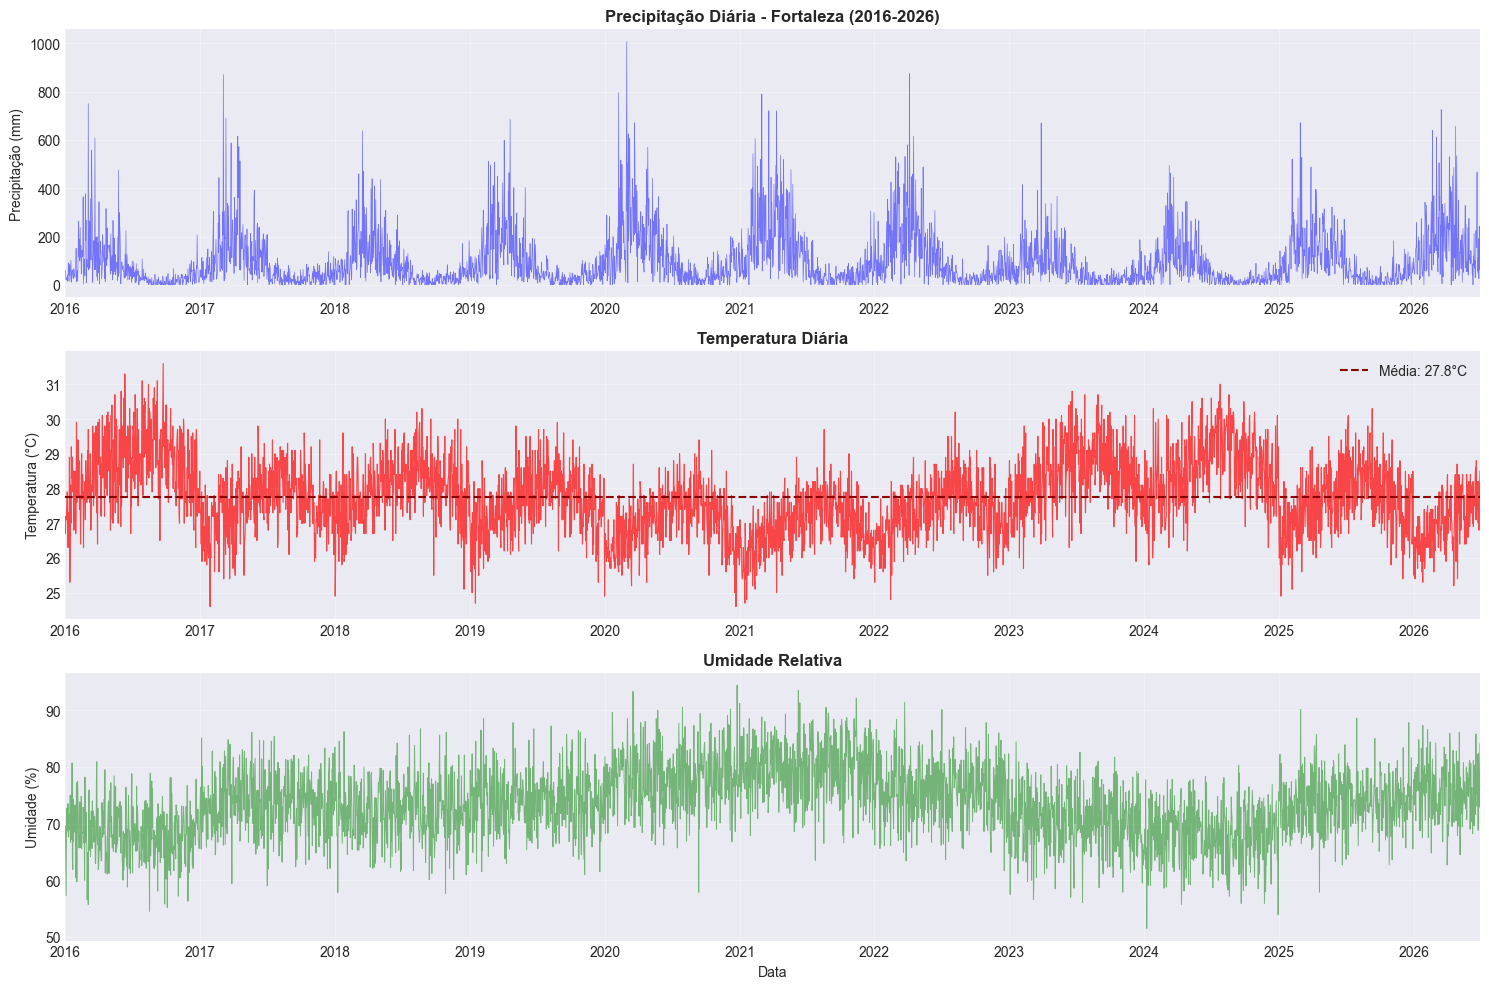

   ✓ Gráfico salvo: reports/figuras/serie_temporal.png


In [8]:
print("\n1. Gerando série temporal...")
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Precipitação
axes[0].plot(df['data'], df['precipitacao_mm'], alpha=0.5, linewidth=0.5, color='blue')
axes[0].set_ylabel('Precipitação (mm)', fontsize=10)
axes[0].set_title('Precipitação Diária - Fortaleza (2016-2026)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(df['data'].min(), df['data'].max())

# Temperatura
axes[1].plot(df['data'], df['temperatura_c'], alpha=0.7, linewidth=0.8, color='red')
media_temp = df['temperatura_c'].mean()
axes[1].axhline(y=media_temp, color='darkred', linestyle='--', linewidth=1.5, label=f"Média: {media_temp:.1f}°C")
axes[1].set_ylabel('Temperatura (°C)', fontsize=10)
axes[1].set_title('Temperatura Diária', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(df['data'].min(), df['data'].max())

# Umidade
axes[2].plot(df['data'], df['umidade_percent'], alpha=0.5, linewidth=0.7, color='green')
axes[2].set_ylabel('Umidade (%)', fontsize=10)
axes[2].set_xlabel('Data', fontsize=10)
axes[2].set_title('Umidade Relativa', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(df['data'].min(), df['data'].max())

plt.tight_layout()
plt.savefig('reports/figuras/serie_temporal.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/serie_temporal.png")

# 2. BOXPLOT POR FENÔMENO CLIMÁTICO


2. Gerando boxplots por fenômeno...


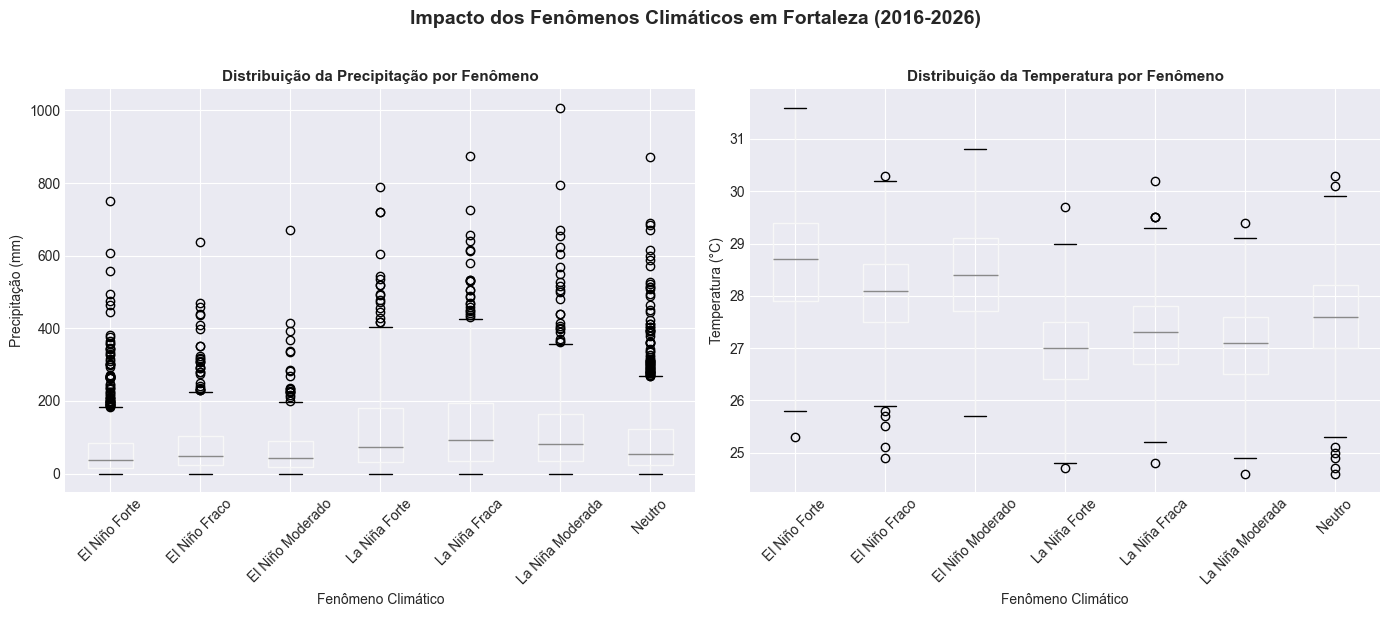

   ✓ Gráfico salvo: reports/figuras/boxplot_fenomenos.png


In [9]:
print("\n2. Gerando boxplots por fenômeno...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Precipitação por fenômeno
df.boxplot(column='precipitacao_mm', by='fenomeno_climatico', ax=axes[0])
axes[0].set_title('Distribuição da Precipitação por Fenômeno', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Fenômeno Climático')
axes[0].set_ylabel('Precipitação (mm)')
axes[0].tick_params(axis='x', rotation=45)

# Temperatura por fenômeno
df.boxplot(column='temperatura_c', by='fenomeno_climatico', ax=axes[1])
axes[1].set_title('Distribuição da Temperatura por Fenômeno', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fenômeno Climático')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Impacto dos Fenômenos Climáticos em Fortaleza (2016-2026)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figuras/boxplot_fenomenos.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/boxplot_fenomenos.png")

# 3. HEATMAP DE CORRELAÇÃO


3. Gerando matriz de correlação...


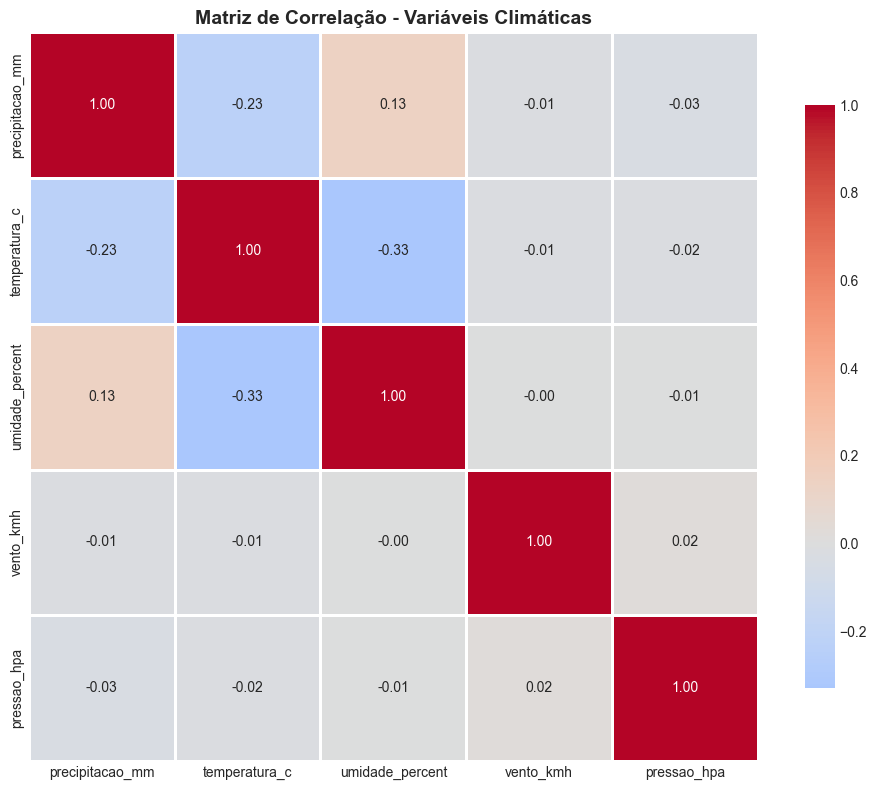

   ✓ Gráfico salvo: reports/figuras/heatmap_correlacao.png


In [10]:
print("\n3. Gerando matriz de correlação...")
plt.figure(figsize=(10, 8))
variaveis = ['precipitacao_mm', 'temperatura_c', 'umidade_percent', 'vento_kmh', 'pressao_hpa']
corr_matrix = df[variaveis].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Variáveis Climáticas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figuras/heatmap_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/heatmap_correlacao.png")

# 4. PERFIL SAZONAL (MÉDIAS MENSAIS)


4. Gerando perfil sazonal...


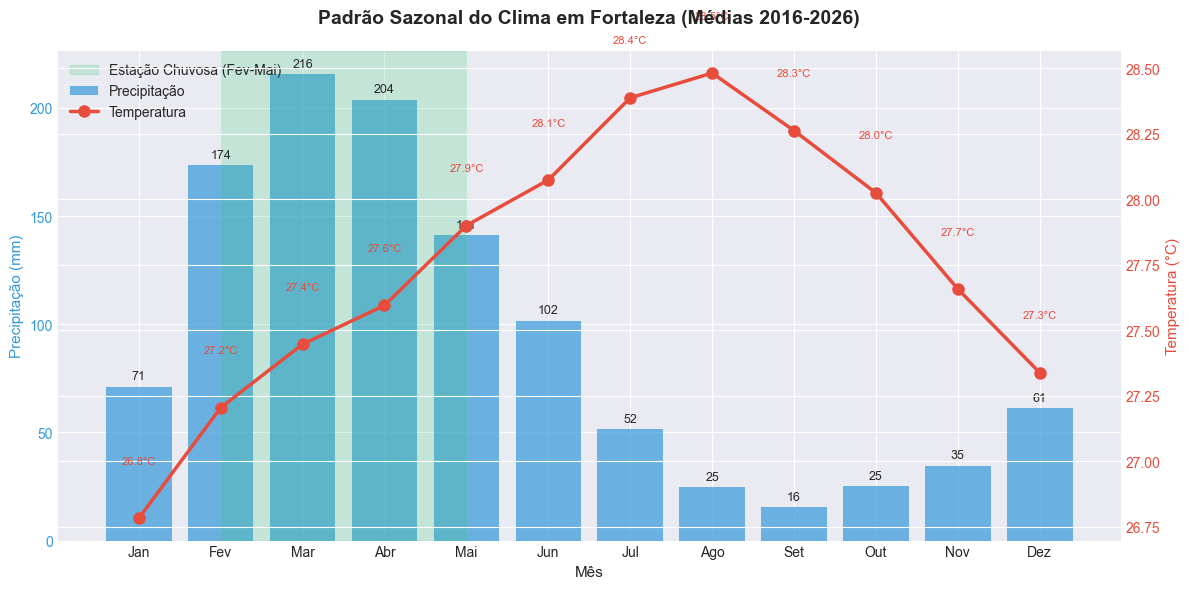

   ✓ Gráfico salvo: reports/figuras/perfil_sazonal.png


In [11]:
print("\n4. Gerando perfil sazonal...")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Precipitação (barras)
meses_num = range(1, 13)
precip_mensal = df.groupby('mes')['precipitacao_mm'].mean()
bars = ax1.bar(meses_num, precip_mensal, alpha=0.7, color='#3498db', label='Precipitação', width=0.8)
ax1.set_xlabel('Mês', fontsize=11)
ax1.set_ylabel('Precipitação (mm)', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(meses_num)
ax1.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Adicionar valores nas barras
for bar, valor in zip(bars, precip_mensal):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{valor:.0f}', ha='center', va='bottom', fontsize=9)

# Temperatura (linha)
ax2 = ax1.twinx()
temp_mensal = df.groupby('mes')['temperatura_c'].mean()
line = ax2.plot(meses_num, temp_mensal, color='#e74c3c', marker='o', linewidth=2.5, 
                markersize=8, label='Temperatura')
ax2.set_ylabel('Temperatura (°C)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Adicionar valores nos pontos
for i, (mes, temp) in enumerate(temp_mensal.items(), 1):
    ax2.text(i, temp + 0.2, f'{temp:.1f}°C', ha='center', va='bottom', fontsize=8, color='#e74c3c')

# Destacar estação chuvosa
ax1.axvspan(2, 5, alpha=0.2, color='#2ecc71', label='Estação Chuvosa (Fev-Mai)')

# Legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Padrão Sazonal do Clima em Fortaleza (Médias 2016-2026)', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('reports/figuras/perfil_sazonal.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/perfil_sazonal.png")

# 5. EVOLUÇÃO ANUAL (LINHAS TREND)


5. Gerando evolução anual com tendência...


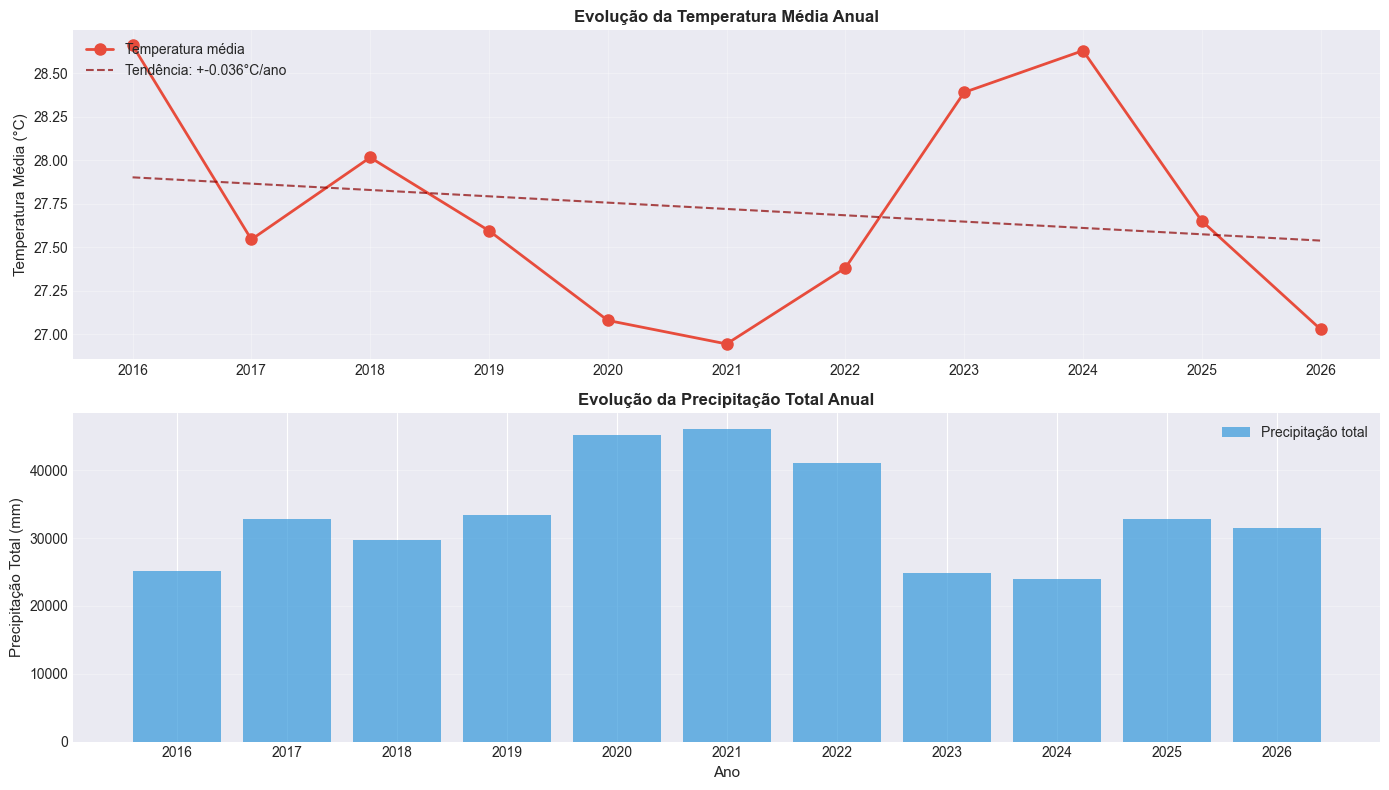

   ✓ Gráfico salvo: reports/figuras/evolucao_anual.png


In [12]:
print("\n5. Gerando evolução anual com tendência...")
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Temperatura anual
temperatura_anual = df.groupby('ano')['temperatura_c'].mean().reset_index()
axes[0].plot(temperatura_anual['ano'], temperatura_anual['temperatura_c'], 
             marker='o', linewidth=2, markersize=8, color='#e74c3c', label='Temperatura média')
axes[0].set_ylabel('Temperatura Média (°C)', fontsize=11)
axes[0].set_title('Evolução da Temperatura Média Anual', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(temperatura_anual['ano'])

# Adicionar linha de tendência
z = np.polyfit(temperatura_anual['ano'], temperatura_anual['temperatura_c'], 1)
p = np.poly1d(z)
axes[0].plot(temperatura_anual['ano'], p(temperatura_anual['ano']), 
            '--', color='darkred', alpha=0.7, label=f'Tendência: +{z[0]:.3f}°C/ano')
axes[0].legend(loc='upper left')

# Precipitação anual
precipitacao_anual = df.groupby('ano')['precipitacao_mm'].sum().reset_index()
axes[1].bar(precipitacao_anual['ano'], precipitacao_anual['precipitacao_mm'], 
            color='#3498db', alpha=0.7, label='Precipitação total')
axes[1].set_ylabel('Precipitação Total (mm)', fontsize=11)
axes[1].set_xlabel('Ano', fontsize=11)
axes[1].set_title('Evolução da Precipitação Total Anual', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(precipitacao_anual['ano'])
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figuras/evolucao_anual.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/evolucao_anual.png")

# 6. MAPA DE CALOR POR MÊS E ANO (PRECIPITAÇÃO)


6. Gerando heatmap sazonal...


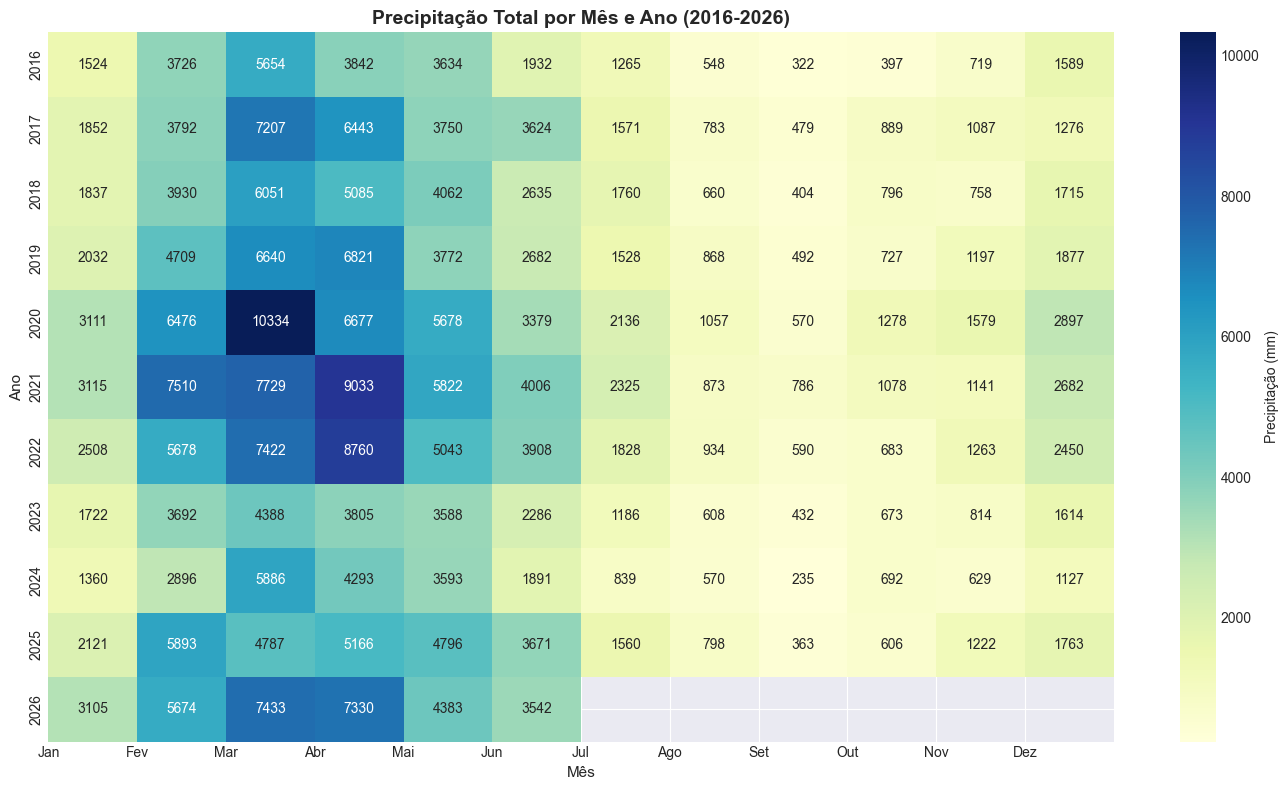

   ✓ Gráfico salvo: reports/figuras/heatmap_precipitacao.png


In [13]:
print("\n6. Gerando heatmap sazonal...")
tabela_precip = df.pivot_table(index='ano', columns='mes', values='precipitacao_mm', aggfunc='sum')
plt.figure(figsize=(14, 8))
sns.heatmap(tabela_precip, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Precipitação (mm)'})
plt.title('Precipitação Total por Mês e Ano (2016-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=11)
plt.ylabel('Ano', fontsize=11)
plt.xticks(ticks=range(12), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.tight_layout()
plt.savefig('reports/figuras/heatmap_precipitacao.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/heatmap_precipitacao.png")

# 7. GRÁFICO DE VIOLINO PARA DISTRIBUIÇÕES


7. Gerando gráficos de violino...


C:\Users\Victor\AppData\Local\Temp\ipykernel_14404\1583309674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='estacao', y='temperatura_c', ax=axes[0], palette='coolwarm')
C:\Users\Victor\AppData\Local\Temp\ipykernel_14404\1583309674.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='estacao', y='precipitacao_mm', ax=axes[1], palette='Blues')


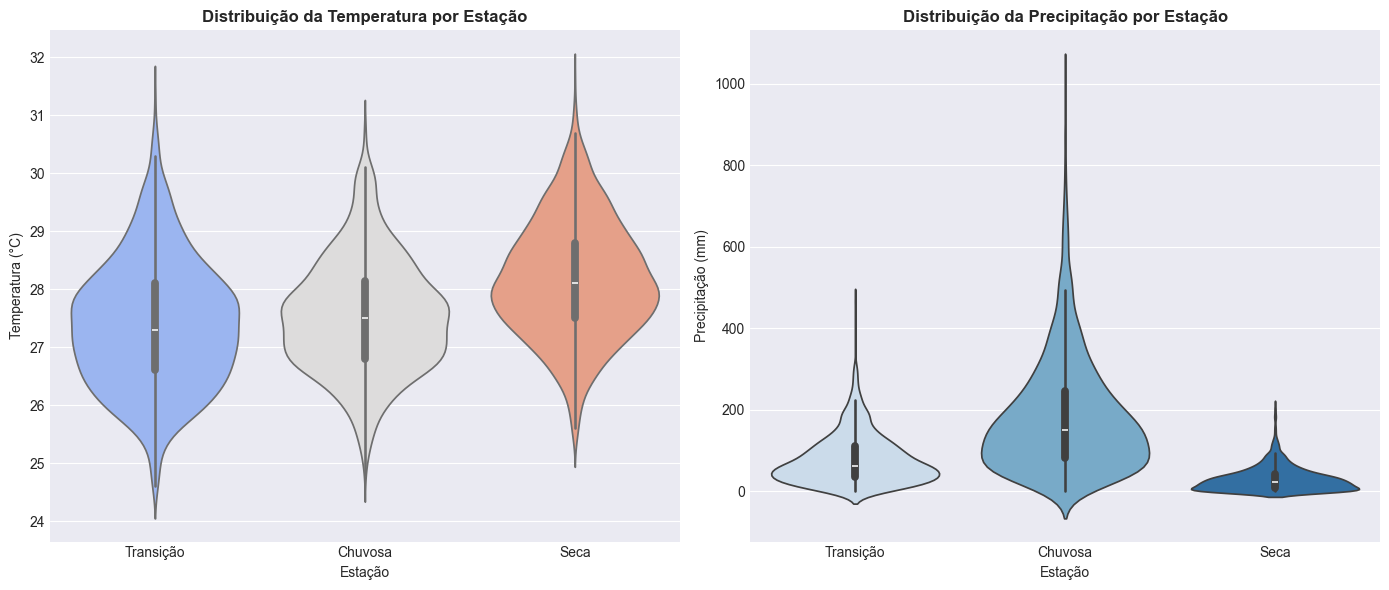

   ✓ Gráfico salvo: reports/figuras/violin_plots.png

✅ TODAS AS VISUALIZAÇÕES FORAM GERADAS COM SUCESSO!
📁 Gráficos salvos em: reports/figuras/

📊 RESUMO DOS DADOS ANALISADOS:
Período: 2016-01-01 a 2026-06-30
Total de dias: 3834
Temperatura média: 27.8°C
Temperatura máxima: 31.6°C
Temperatura mínima: 24.6°C
Precipitação total: 366315 mm
Precipitação média diária: 95.5 mm


In [14]:
print("\n7. Gerando gráficos de violino...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribuição de temperatura por estação
df_temp = df.copy()
sns.violinplot(data=df_temp, x='estacao', y='temperatura_c', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribuição da Temperatura por Estação', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estação', fontsize=10)
axes[0].set_ylabel('Temperatura (°C)', fontsize=10)

# Distribuição de precipitação por estação
sns.violinplot(data=df_temp, x='estacao', y='precipitacao_mm', ax=axes[1], palette='Blues')
axes[1].set_title('Distribuição da Precipitação por Estação', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estação', fontsize=10)
axes[1].set_ylabel('Precipitação (mm)', fontsize=10)

plt.tight_layout()
plt.savefig('reports/figuras/violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Gráfico salvo: reports/figuras/violin_plots.png")

print("\n" + "="*60)
print("✅ TODAS AS VISUALIZAÇÕES FORAM GERADAS COM SUCESSO!")
print(f"📁 Gráficos salvos em: reports/figuras/")
print("="*60)

# Mostrar estatísticas rápidas
print("\n📊 RESUMO DOS DADOS ANALISADOS:")
print(f"Período: {df['data'].min().date()} a {df['data'].max().date()}")
print(f"Total de dias: {len(df)}")
print(f"Temperatura média: {df['temperatura_c'].mean():.1f}°C")
print(f"Temperatura máxima: {df['temperatura_c'].max():.1f}°C")
print(f"Temperatura mínima: {df['temperatura_c'].min():.1f}°C")
print(f"Precipitação total: {df['precipitacao_mm'].sum():.0f} mm")
print(f"Precipitação média diária: {df['precipitacao_mm'].mean():.1f} mm")